# Population: Sexes by age in Ireland

## Part 1: Differences between sexes by age in Ireland

- Weighted mean age (by sex)

- The difference between the sexes by age - This part does not need to look at the regions.

ie You can take the notebook I used in the lectures and substitute the sexes for the regions.

In [1]:
# Import necessary libraries

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
FILENAME = "cso_populationbyageandsex.csv"
DATADIR = "data/"
FULLPATH = DATADIR + FILENAME

# Read the CSV file into a Data Frame
df = pd.read_csv(FULLPATH)


In [3]:
drop_col_list = ["Statistic Label","CensusYear","UNIT"]
df.drop(columns=drop_col_list, inplace=True)

In [4]:
print(df.columns.tolist())

['Sex', 'Single Year of Age', 'Administrative Counties', 'VALUE']


In [5]:
# Removing all ages
df = df[df["Single Year of Age"] != "All ages"]

# Changing the columns using a find and replace
df ["Single Year of Age"] = df ["Single Year of Age"].astype(str).str.replace("Under 1 year","0")
df ["Single Year of Age"] = df ["Single Year of Age"].astype(str).str.replace("100 years and over","100")

# Removing all non-digit characters from the selected column
df["Single Year of Age"] = df["Single Year of Age"].str.replace(r"\D", "", regex=True)

# Make sure the column is an integer for plotting later
df["Single Year of Age"] = df["Single Year of Age"].astype("int64")

display(df.head())
display(df.tail())



,Sex,Single Year of Age,Administrative Counties,VALUE
32,Both sexes,0,Ireland,57796
33,Both sexes,0,Carlow County Council,699
34,Both sexes,0,Dublin City Council,6213
35,Both sexes,0,Dún Laoghaire Rathdown County Council,2457
36,Both sexes,0,Fingal County Council,4009


,Sex,Single Year of Age,Administrative Counties,VALUE
9787,Female,100,Roscommon County Council,7
9788,Female,100,Sligo County Council,9
9789,Female,100,Cavan County Council,12
9790,Female,100,Donegal County Council,31
9791,Female,100,Monaghan County Council,7


In [6]:
# Creating a pivot table for population analysis by age and sex
df_analysis = pd.pivot_table(df, "VALUE", "Single Year of Age", "Sex")

# df_analysis.to_csv("population_by_age_and_sex.csv")
display(df_analysis)

Sex,Both sexes,Female,Male
Single Year of Age,,,
0,3612.2500,1761.6250,1850.6250
1,3526.2500,1721.5625,1804.6875
2,3700.6250,1810.8750,1889.7500
3,3780.2500,1842.6875,1937.5625
4,3844.0625,1863.6875,1980.3750
...,...,...,...
96,80.1875,59.7500,20.4375
97,59.3125,45.7500,13.5625
98,38.8750,30.7500,8.1250


Sex     Both sexes       Female         Male
count   101.000000   101.000000   101.000000
mean   3186.348391  1611.751238  1574.597153
std    1568.996088   774.327526   797.010584
min      27.562500    21.000000     6.562500
25%    2235.437500  1143.375000  1092.062500
50%    3777.187500  1863.687500  1889.625000
75%    4337.812500  2155.562500  2182.875000
max    5318.562500  2731.000000  2602.750000


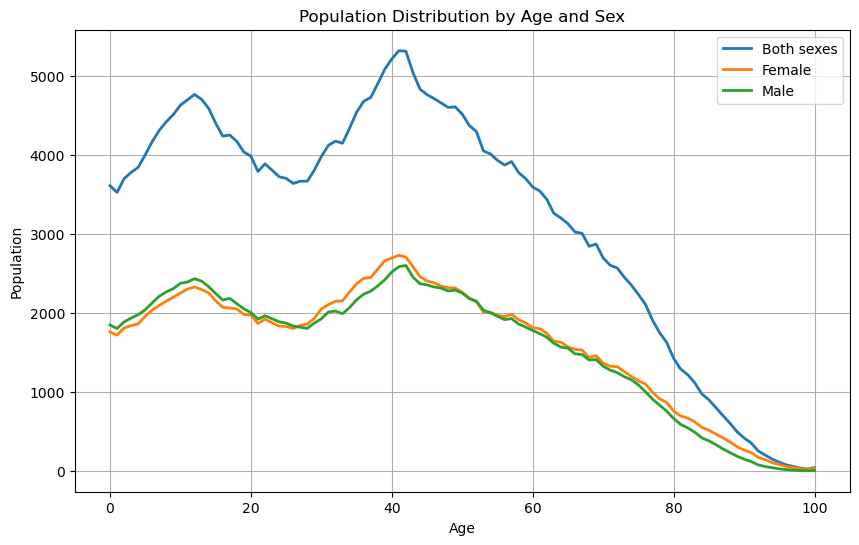

In [7]:
# Now, we'll calculate the mean age by sex
print(df_analysis.describe())

# Let's plot the population distribution by age and sex so we can better visualise the Irish population
plt.figure(figsize=(10, 6))
plt.plot(df_analysis.index, df_analysis, marker='', linewidth=2)
plt.title("Population Distribution by Age and Sex")
plt.xlabel("Age")
plt.ylabel("Population")
plt.legend(df_analysis.columns)
plt.grid()


In [8]:
# Now, we'll calculate the mean age by sex
# Using the lambda function to calculate weighted average, where x.index is the age and x.values is the population count
mean_ages = df_analysis.apply(lambda x: np.average(x.index, weights=x.values))

# Showing the mean ages by sex
print("Mean ages by sex:")
print(mean_ages)

Mean ages by sex:
Sex
Both sexes    38.346620
Female        38.939796
Male          37.739448
dtype: float64


Single Year of Age
0       89.0000
1       83.1250
2       78.8750
3       94.8750
4      116.6875
         ...   
96     -39.3125
97     -32.1875
98     -22.6250
99     -14.4375
100    -26.8750
Length: 101, dtype: float64

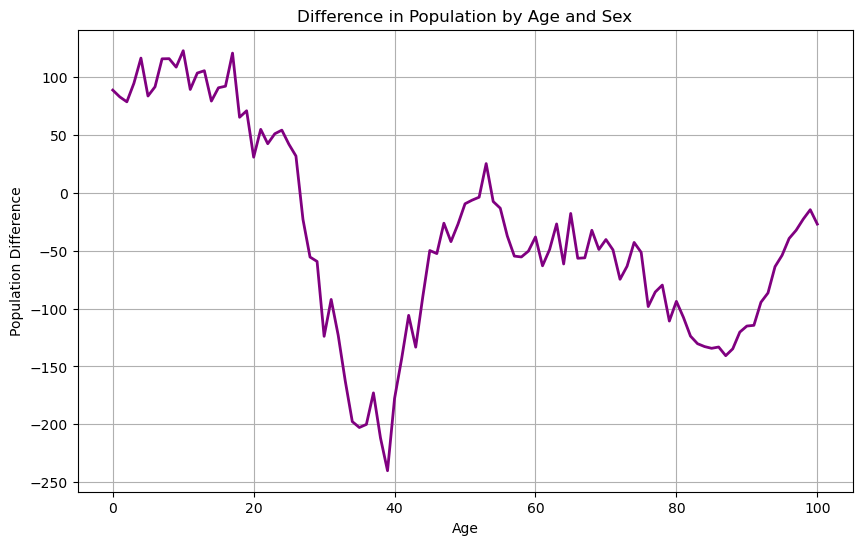

In [9]:
# And we'll calculate the difference between sexes by age
age_diff = df_analysis['Male'] - df_analysis['Female']

# Display the age difference data
display(age_diff)

# Now, we plot the difference in population

plt.figure(figsize=(10, 6))
plt.plot(age_diff.index, age_diff, marker='', linewidth=2, color='purple')
plt.title("Difference in Population by Age and Sex")
plt.xlabel("Age")
plt.ylabel("Population Difference")
plt.grid()
plt.show()

In [10]:
# Finally, for part one, we'll calculate some statistics on the population data
stats = df_analysis.describe()

#And we'll eliminate the "Both sexes" Column for clarity
df_analysis = stats .drop(columns =["Both sexes"], errors='ignore')

display(df_analysis)

Sex,Female,Male
count,101.000000,101.000000
mean,1611.751238,1574.597153
std,774.327526,797.010584
min,21.000000,6.562500
25%,1143.375000,1092.062500
50%,1863.687500,1889.625000
75%,2155.562500,2182.875000
max,2731.000000,2602.750000


# Part 2 - Make a variable that stores an age (e.g. 35)

Write code that would group the people within 5 years of that age together, into one age group 

Calculate the population difference between the sexes in that age group.

In [11]:
# Calculating the total population within a specific age range (e.g., 30-40 years)
target_age = 35

# Filtering the DataFrame for the target age range, then grouping by sex and summing the values
group = df[(df["Single Year of Age"] >= target_age - 5) & (df["Single Year of Age"] <= target_age + 5)]
grouped = group.groupby("Sex")["VALUE"].sum()

# Display the results
display(grouped)

Sex
Both sexes    1597072
Female         829012
Male           768060
Name: VALUE, dtype: int64

# Part 3 - Biggest population difference between the sexes in that age group

Region With the Largest Difference

The dataset needs:

 - Region

 - Sex

 - Population

 - Age

In [ ]:
# And for this part, firstly, we'll take a look at population by region and ages (e.g. 30-40 years)
by_region = group.groupby(["Administrative Counties", "Single Year of Age"])["VALUE"].sum().unstack()
display(by_region)

Single Year of Age,30,31,32,33,34,35,36,37,38,39,40
Administrative Counties,,,,,,,,,,,
Carlow County Council,1410,1478,1492,1500,1548,1666,1670,1816,1896,2012,1962
Cavan County Council,1682,1814,1992,1910,1976,2158,2302,2364,2534,2594,2526
Clare County Council,2418,2662,2660,2676,2910,3032,3186,3422,3636,3548,3812
Cork City Council,6874,7162,7128,6676,6820,6934,6922,7262,6930,7158,7258
Cork County Council,7090,7390,7682,7866,8508,9222,9564,9932,10368,11276,11604
Donegal County Council,3388,3446,3726,3658,4046,4032,4224,4212,4310,4716,4884
Dublin City Council,24682,24732,24088,22868,22096,21864,21238,20220,20272,19796,19540
Dún Laoghaire Rathdown County Council,6224,6130,6330,6046,6088,6108,6376,6474,6890,7090,7292
Fingal County Council,7952,8482,8656,9192,9574,10024,10654,10672,11216,11854,12208


In [13]:
# Creating a proper pivot table with sex as columns
by_region_sex = group.groupby(["Administrative Counties", "Sex"])["VALUE"].sum().unstack(fill_value=0)

# Now calculate the difference between Male and Female populations
by_region_sex["Difference"] = by_region_sex["Male"] - by_region_sex["Female"]

# Display the results
display(by_region_sex)

Sex,Both sexes,Female,Male,Difference
Administrative Counties,,,,
Carlow County Council,9225,4774,4451,-323
Cavan County Council,11926,6150,5776,-374
Clare County Council,16981,8896,8085,-811
Cork City Council,38562,19750,18812,-938
Cork County Council,50251,26545,23706,-2839
Donegal County Council,22321,11700,10621,-1079
Dublin City Council,120698,59831,60867,1036
Dún Laoghaire Rathdown County Council,35524,18450,17074,-1376
Fingal County Council,55242,29092,26150,-2942
